In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
print("Setup Selesai")


Setup Selesai


In [2]:
df = pd.read_csv('data_pegawai_retail.csv')

In [3]:
df.head()


,Tgl_Masuk,Kota_Domisili,Gaji_Bulanan,Jam_Kerja_Bulanan,Departemen
0,2018/01/01,Kota_29,8500000.0,154.0,Sales
1,2018/01/11,Kota_15,11000000.0,162.0,IT
2,2018/01/21,Kota_8,990000000.0,160.0,HR
3,2018/01/31,Kota_21,5100000.0,171.0,Sales
4,2018/02/10,Kota_19,6900000.0,189.0,HR


In [4]:
print("Jumlah baris sebelum hapus duplikat:", len(df))
df = df.drop_duplicates()
print("Jumlah baris setelah hapus duplikat:", len(df))

Jumlah baris sebelum hapus duplikat: 155
Jumlah baris setelah hapus duplikat: 150


In [5]:
df['Tgl_Masuk'] = pd.to_datetime(df['Tgl_Masuk'])

kolom_kategorikal = ['Kota_Domisili', 'Departemen']
for kolom in kolom_kategorikal:
    df[kolom] = df[kolom].astype('category')

print(df.dtypes)

Tgl_Masuk            datetime64[us]
Kota_Domisili              category
Gaji_Bulanan                float64
Jam_Kerja_Bulanan           float64
Departemen                 category
dtype: object


In [6]:
df.isnull().sum()


Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         3
Jam_Kerja_Bulanan    3
Departemen           3
dtype: int64

In [8]:
kolom_kategorikal = ['Kota_Domisili', 'Departemen']
for kolom in kolom_kategorikal:
    if kolom in df.columns:
        # 1. Tambahkan "Tidak Diketahui" sebagai kategori baru yang sah
        df[kolom] = df[kolom].cat.add_categories(["Tidak Diketahui"])
        
        # 2. Isi missing value dengan kategori tersebut
        df[kolom] = df[kolom].fillna("Tidak Diketahui")

In [9]:
df.isnull().sum()


Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         0
Jam_Kerja_Bulanan    0
Departemen           0
dtype: int64

In [12]:
df.describe()

,Tgl_Masuk,Gaji_Bulanan,Jam_Kerja_Bulanan
count,150,1.500000e+02,150.000000
mean,2020-01-16 00:00:00,2.103667e+07,159.960000
min,2018-01-01 00:00:00,4.500000e+06,122.000000
25%,2019-01-08 12:00:00,7.000000e+06,150.000000
50%,2020-01-16 00:00:00,7.900000e+06,160.000000
75%,2021-01-22 12:00:00,8.900000e+06,169.000000
max,2022-01-30 00:00:00,9.900000e+08,209.000000
std,NaN,1.130267e+08,15.036814


In [13]:
df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan']].skew()

Gaji_Bulanan         8.569786
Jam_Kerja_Bulanan    0.169410
dtype: float64

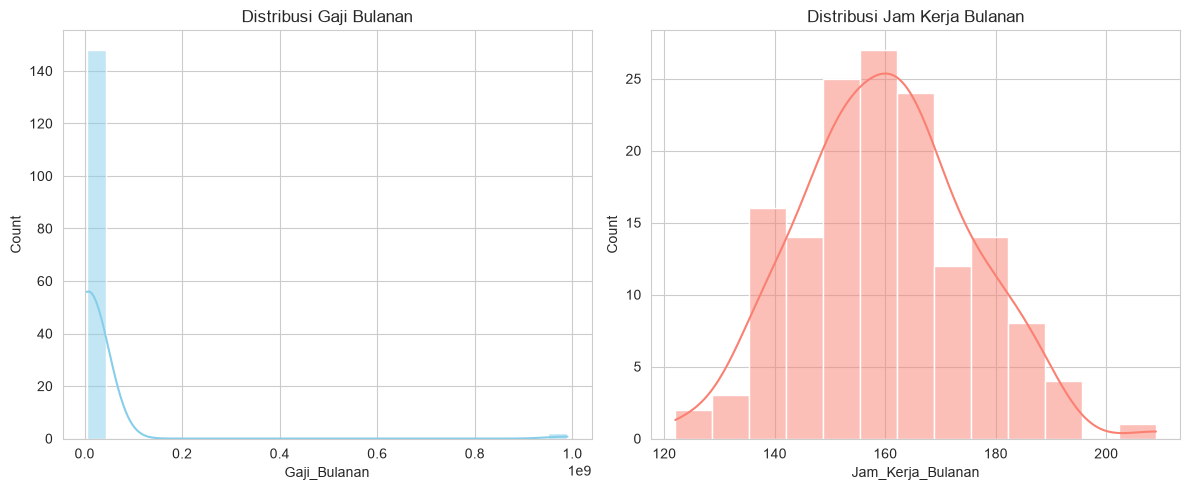

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Gaji_Bulanan'], kde=True, color='skyblue')
plt.title('Distribusi Gaji Bulanan')

plt.subplot(1, 2, 2)
sns.histplot(df['Jam_Kerja_Bulanan'], kde=True, color='salmon')
plt.title('Distribusi Jam Kerja Bulanan')

plt.tight_layout()
plt.show()

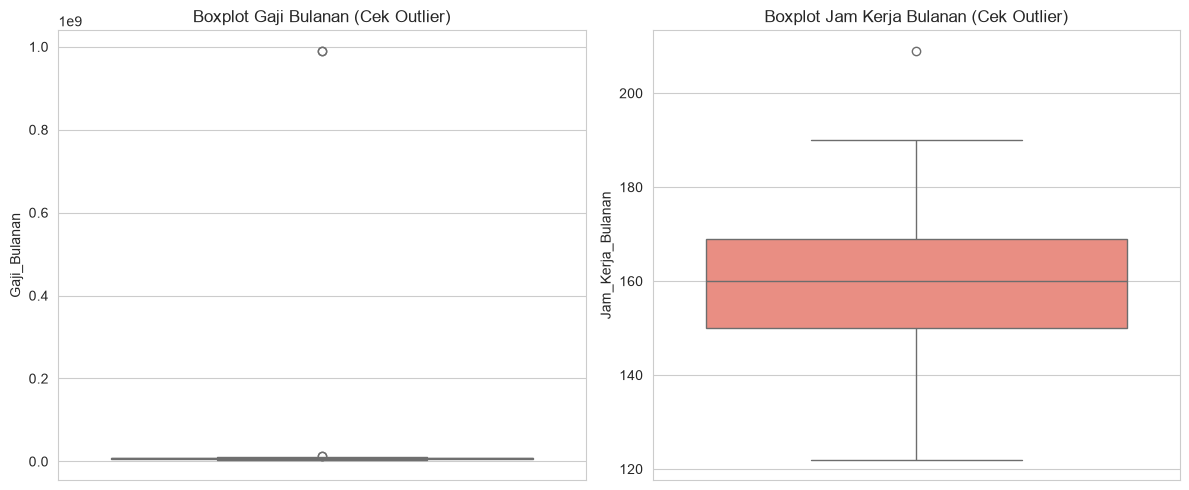

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Gaji_Bulanan'], color='skyblue')
plt.title('Boxplot Gaji Bulanan (Cek Outlier)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Jam_Kerja_Bulanan'], color='salmon')
plt.title('Boxplot Jam Kerja Bulanan (Cek Outlier)')

plt.tight_layout()
plt.show()

In [16]:
print(df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan']].skew())

Gaji_Bulanan         8.569786
Jam_Kerja_Bulanan    0.169410
dtype: float64


--- Value Counts untuk Kota_Domisili ---
Kota_Domisili
Kota_24            9
Kota_15            8
Kota_2             8
Kota_28            8
Kota_8             7
Kota_1             6
Kota_14            6
Kota_32            6
Kota_33            6
Kota_9             6
Kota_23            5
Kota_25            5
Kota_26            5
Kota_27            5
Kota_3             5
Kota_7             5
Kota_11            4
Kota_21            4
Kota_22            4
Kota_29            4
Kota_4             4
Kota_12            3
Kota_13            3
Kota_17            3
Kota_18            3
Kota_30            3
Kota_6             3
Kota_16            2
Kota_19            2
Kota_20            2
Kota_34            2
Kota_5             2
Kota_10            1
Kota_31            1
Tidak Diketahui    0
Name: count, dtype: int64


--- Value Counts untuk Departemen ---
Departemen
IT                 43
Sales              40
HR                 34
Finance            30
Tidak Diketahui     3
Name: count, dtype: int

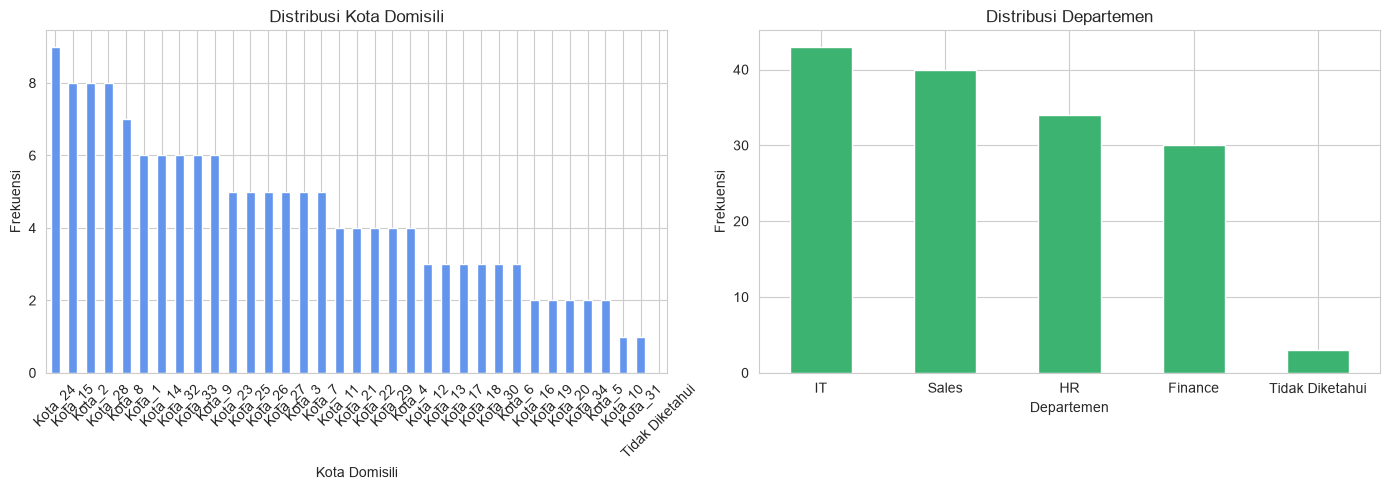

In [17]:
# 1. Menampilkan frekuensi nilai menggunakan value_counts() untuk kolom kategorikal
kolom_kategorikal = ['Kota_Domisili', 'Departemen']
for kolom in kolom_kategorikal:
    if kolom in df.columns:
        print(f"--- Value Counts untuk {kolom} ---")
        print(df[kolom].value_counts())
        print("\n")

# 2. Membuat Bar Chart untuk visualisasi distribusi kategori
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df['Kota_Domisili'].value_counts().plot(kind='bar', color='cornflowerblue')
plt.title('Distribusi Kota Domisili')
plt.xlabel('Kota Domisili')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['Departemen'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Distribusi Departemen')
plt.xlabel('Departemen')
plt.ylabel('Frekuensi')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
kolom_kategorikal = ['Kota_Domisili', 'Departemen']
for kolom in kolom_kategorikal:
    if kolom in df.columns:
        print(f"--- Value Counts untuk {kolom} ---")
        print(df[kolom].value_counts())
        print("\n")

--- Value Counts untuk Kota_Domisili ---
Kota_Domisili
Kota_24            9
Kota_15            8
Kota_2             8
Kota_28            8
Kota_8             7
Kota_1             6
Kota_14            6
Kota_32            6
Kota_33            6
Kota_9             6
Kota_23            5
Kota_25            5
Kota_26            5
Kota_27            5
Kota_3             5
Kota_7             5
Kota_11            4
Kota_21            4
Kota_22            4
Kota_29            4
Kota_4             4
Kota_12            3
Kota_13            3
Kota_17            3
Kota_18            3
Kota_30            3
Kota_6             3
Kota_16            2
Kota_19            2
Kota_20            2
Kota_34            2
Kota_5             2
Kota_10            1
Kota_31            1
Tidak Diketahui    0
Name: count, dtype: int64


--- Value Counts untuk Departemen ---
Departemen
IT                 43
Sales              40
HR                 34
Finance            30
Tidak Diketahui     3
Name: count, dtype: int

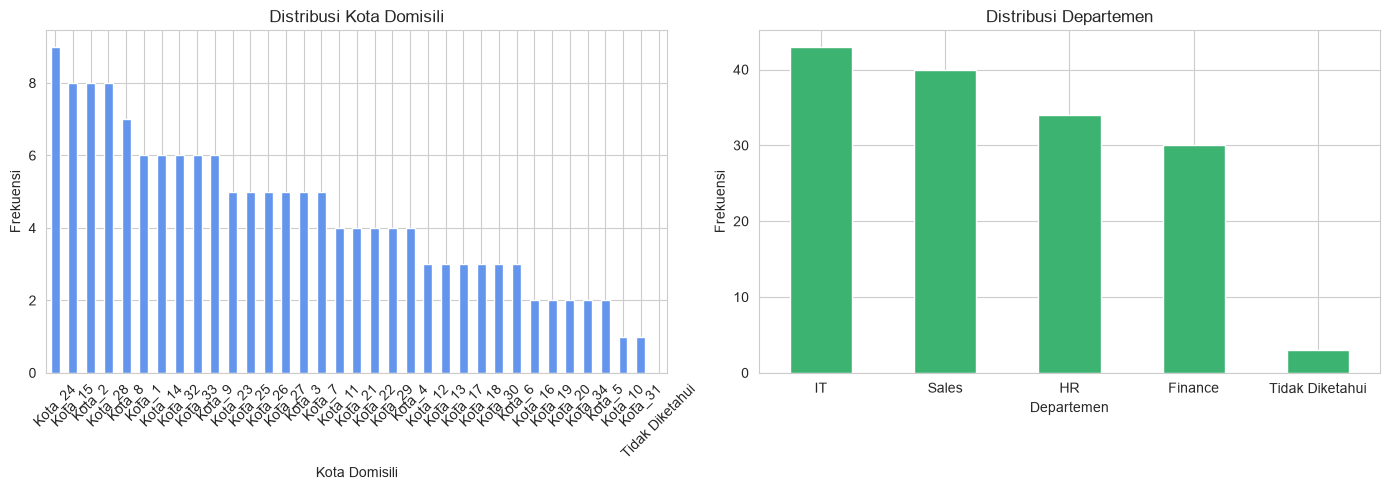

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df['Kota_Domisili'].value_counts().plot(kind='bar', color='cornflowerblue')
plt.title('Distribusi Kota Domisili')
plt.xlabel('Kota Domisili')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df['Departemen'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Distribusi Departemen')
plt.xlabel('Departemen')
plt.ylabel('Frekuensi')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
korelasi = df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan']].corr()
print("Matriks Korelasi:")
print(korelasi)

Matriks Korelasi:
                   Gaji_Bulanan  Jam_Kerja_Bulanan
Gaji_Bulanan           1.000000           0.011957
Jam_Kerja_Bulanan      0.011957           1.000000


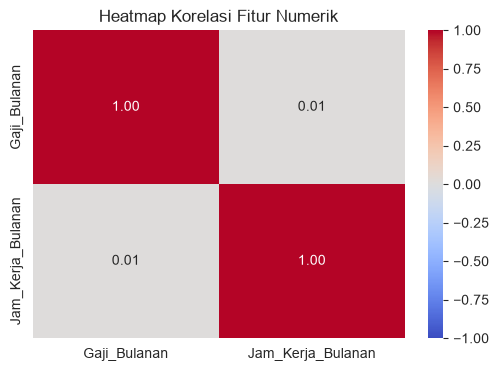

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

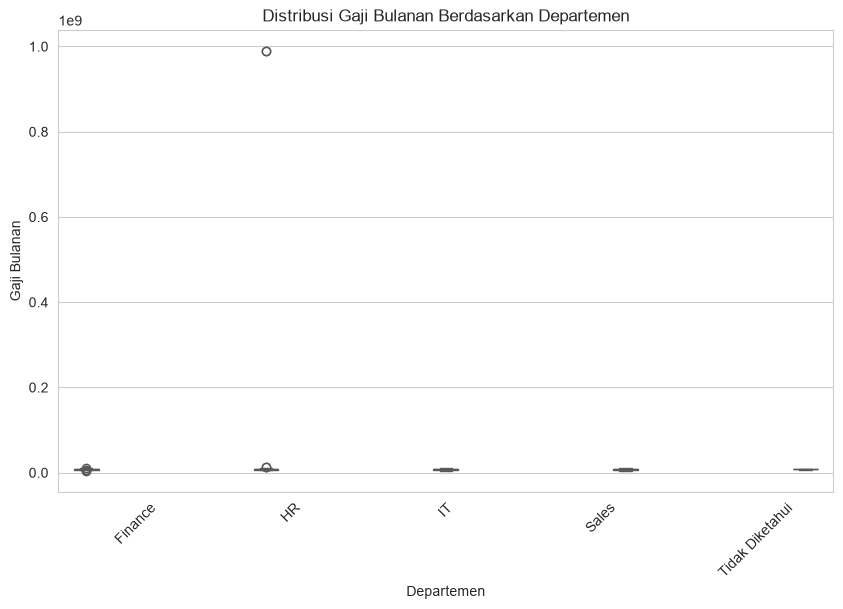

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Departemen', y='Gaji_Bulanan', data=df, palette='Set2', hue='Departemen', legend=False)
plt.title('Distribusi Gaji Bulanan Berdasarkan Departemen')
plt.xlabel('Departemen')
plt.ylabel('Gaji Bulanan')
plt.xticks(rotation=45)
plt.show()

In [24]:
# Menghitung masa kerja dalam satuan tahun dari kolom Tgl_Masuk
tanggal_referensi = pd.to_datetime('2022-12-31')
df['Masa_Kerja_Tahun'] = (tanggal_referensi - df['Tgl_Masuk']).dt.days / 365.25

# Menampilkan beberapa baris pertama untuk verifikasi kolom baru
print(df[['Tgl_Masuk', 'Masa_Kerja_Tahun']].head())

   Tgl_Masuk  Masa_Kerja_Tahun
0 2018-01-01          4.996578
1 2018-01-11          4.969199
2 2018-01-21          4.941821
3 2018-01-31          4.914442
4 2018-02-10          4.887064


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tgl_Masuk          150 non-null    datetime64[us]
 1   Kota_Domisili      150 non-null    category      
 2   Gaji_Bulanan       150 non-null    float64       
 3   Jam_Kerja_Bulanan  150 non-null    float64       
 4   Departemen         150 non-null    category      
 5   Masa_Kerja_Tahun   150 non-null    float64       
dtypes: category(2), datetime64[us](1), float64(3)
memory usage: 6.9 KB


In [26]:
df.isnull().sum()

Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         0
Jam_Kerja_Bulanan    0
Departemen           0
Masa_Kerja_Tahun     0
dtype: int64

## **DATA SIAP UNTuk TAHAP PREPROCESSING**

Berdasarkan rangkaian proses Exploratory Data Analysis (EDA) yang telah dilakukan, dataset retail pegawai kini telah bersih dari *missing value*, tipe data telah dikoreksi dengan tepat, serta karakteristik distribusi dan korelasinya telah dipahami secara mendalam.

### Saran Algoritma Machine Learning
Rekomendasi algoritma yang paling cocok digunakan untuk dataset ini adalah **Random Forest** atau **XGBoost**. Alasan utamanya karena dataset kita memiliki *outlier* yang sangat ekstrem (terutama pada kolom `Gaji_Bulanan` dengan nilai *skewness* mencapai 8,57) serta hubungan antar-fitur numerik yang tidak linier (korelasi antara jam kerja dan gaji mendekati nol). Algoritma berbasis *tree* (pohon keputusan) sangat ideal karena tahan terhadap *outlier*, tidak sensitif terhadap skala data yang timpang, dan mampu menangkap pola hubungan yang kompleks tanpa memerlukan asumsi distribusi normal.

### Catatan Khusus
Hal yang paling mengejutkan dari data ini selama proses EDA adalah adanya lonjakan *outlier* ekstrem pada `Gaji_Bulanan` yang mencapai hampir 1 miliar, padahal nilai median dan sebagian besar gaji pegawai riil di perusahaan tersebut berada di kisaran 7 hingga 8 juta rupiah saja.